<a href="https://colab.research.google.com/github/pozdnyavladimer-jpg/geometric-state-navigator/blob/main/%D0%9A%D0%BE%D0%BF%D1%96%D1%8F_%D0%B7%D0%B0%D0%BF%D0%B8%D1%81%D0%BD%D0%B8%D0%BA%D0%B0_%22Untitled19_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

np.random.seed(42)

# =========================================================
# CONFIG
# =========================================================
N_PETALS = 19
OCTAVES = [9, 6, 3, 1]   # 19 = 9 + 6 + 3 + 1
HEX_KEYS = [
    "red_mass",
    "orange_flow",
    "yellow_struct",
    "green_balance",
    "blue_law",
    "violet_future",
]

COLORS = {
    "red_mass": "#ff4d4d",
    "orange_flow": "#ffb347",
    "yellow_struct": "#ffe44d",
    "green_balance": "#5cff8a",
    "blue_law": "#66b3ff",
    "violet_future": "#d46bff",
}

TARGET = {
    "red_mass": 0.05,
    "orange_flow": 0.30,
    "yellow_struct": 0.32,
    "green_balance": 0.34,
    "blue_law": 0.12,
    "violet_future": 0.12,
}

STEPS = 45
SPIRAL_TURNS = 1.6
TOTAL_HEIGHT = 2.4
BASE_RADIUS = 1.15
BINDU_HOLD_CYCLES = 2

# =========================================================
# HELPERS
# =========================================================
def normalize(v):
    s = sum(max(v[k], 0.0) for k in v)
    if s <= 1e-9:
        return {k: 1.0 / len(v) for k in v}
    return {k: max(v[k], 0.0) / s for k in v}

def random_state():
    v = {
        "red_mass": np.random.uniform(0.22, 0.40),
        "orange_flow": np.random.uniform(0.06, 0.16),
        "yellow_struct": np.random.uniform(0.08, 0.18),
        "green_balance": np.random.uniform(0.08, 0.18),
        "blue_law": np.random.uniform(0.06, 0.14),
        "violet_future": np.random.uniform(0.04, 0.12),
    }
    return normalize(v)

def alignment_distance(v):
    g = v["green_balance"]
    y = v["yellow_struct"]
    o = v["orange_flow"]
    return abs(g - y) + abs(y - o) + abs(g - o)

def vec_distance_to_target(v):
    return sum(abs(v[k] - TARGET[k]) for k in HEX_KEYS)

def compute_vitality(v):
    return (
        v["orange_flow"]
        + v["yellow_struct"]
        + v["green_balance"]
        + 0.5 * v["violet_future"]
    )

def compute_global_state(field):
    avg = {k: float(np.mean([node["state"][k] for node in field])) for k in HEX_KEYS}
    shadow = float(np.mean([node["state"]["red_mass"] for node in field]))
    coherence = 1.0 - min(1.0, alignment_distance(avg) * 2.0)
    target_fit = 1.0 - min(1.0, vec_distance_to_target(avg) * 1.1)
    vitality = compute_vitality(avg)

    if shadow > 0.22:
        phase = "water"
    elif shadow > 0.12:
        phase = "gas"
    elif shadow <= 0.12 and coherence > 0.88 and vitality > 0.74:
        phase = "plasma"
    elif shadow <= 0.08 and coherence > 0.93 and vitality > 0.82 and target_fit > 0.68:
        phase = "crystal"
    else:
        phase = "gas"

    return avg, shadow, coherence, target_fit, vitality, phase

def is_near_bindu_open(avg, shadow, coherence, target_fit, vitality):
    return (
        shadow <= 0.10 and
        coherence >= 0.90 and
        vitality >= 0.74
    )

In [ ]:

# =========================================================
# 3D FIELD
# =========================================================
def generate_3d_spiral_field():
    field = []
    idx = 0

    for layer_idx, count in enumerate(OCTAVES):
        z = (layer_idx / (len(OCTAVES) - 1)) * TOTAL_HEIGHT
        radius = BASE_RADIUS * (1.0 - 0.22 * layer_idx)

        for _ in range(count):
            t = idx / (N_PETALS - 1)
            angle = 2 * np.pi * SPIRAL_TURNS * t
            x = radius * np.cos(angle)
            y = radius * np.sin(angle)

            field.append({
                "id": idx,
                "xyz": np.array([x, y, z], dtype=float),
                "layer": layer_idx,
                "angle": angle,
                "state": random_state(),
            })
            idx += 1

    return field

# =========================================================
# DYNAMICS
# =========================================================
def move_shadow(field, shadow_idx, jump=3, strength=0.055):
    old = field[shadow_idx]
    old["state"]["red_mass"] *= 0.82
    old["state"]["green_balance"] += 0.01
    old["state"]["yellow_struct"] += 0.01
    old["state"] = normalize(old["state"])

    new_idx = (shadow_idx + jump) % len(field)
    new = field[new_idx]
    new["state"]["red_mass"] += strength
    new["state"]["orange_flow"] += strength * 0.18
    new["state"]["green_balance"] -= strength * 0.08
    new["state"]["yellow_struct"] -= strength * 0.05
    new["state"] = normalize(new["state"])

    return new_idx

def local_3d_mix(field, idx, dist_scale=1.4, neighbor_weight=0.24, vertical_weight=0.18):
    cur = field[idx]
    cur_xyz = cur["xyz"]
    cur_v = cur["state"]

    acc = {k: 0.0 for k in HEX_KEYS}
    total_w = 0.0

    for j, other in enumerate(field):
        if j == idx:
            continue

        d = np.linalg.norm(cur_xyz - other["xyz"])
        w_dist = np.exp(-dist_scale * d) * 0.18

        spiral_gap = abs(j - idx)
        w_spiral = neighbor_weight if spiral_gap == 1 else 0.0

        same_sector = abs((other["angle"] - cur["angle"] + np.pi) % (2*np.pi) - np.pi) < 0.65
        layer_gap = abs(other["layer"] - cur["layer"])
        w_vertical = vertical_weight if same_sector and layer_gap == 1 else 0.0

        w = w_dist + w_spiral + w_vertical
        if w <= 0:
            continue

        for k in HEX_KEYS:
            acc[k] += other["state"][k] * w
        total_w += w

    if total_w <= 1e-9:
        return dict(cur_v)

    mixed = {}
    for k in HEX_KEYS:
        neighbor_mean = acc[k] / total_w
        mixed[k] = 0.68 * cur_v[k] + 0.32 * neighbor_mean

    return normalize(mixed)

def pulse_6_mix(field):
    new_states = [local_3d_mix(field, i) for i in range(len(field))]
    for i in range(len(field)):
        field[i]["state"] = new_states[i]
    return field

bindu_hold_counter = 0

def pulse_9_gate(field):
    global bindu_hold_counter

    avg, shadow, coherence, target_fit, vitality, phase = compute_global_state(field)
    bindu_now = is_near_bindu_open(avg, shadow, coherence, target_fit, vitality)

    if bindu_now:
        bindu_hold_counter = BINDU_HOLD_CYCLES

    hold_mode = bindu_hold_counter > 0

    new_states = []
    for node in field:
        v = dict(node["state"])
        layer = node["layer"]

        # --- shadow transform ---
        red_before = v["red_mass"]
        v["red_mass"] *= 0.80
        converted = max(0.0, red_before - v["red_mass"])

        v["violet_future"] += converted * 0.48
        v["orange_flow"] += converted * 0.30

        # --- base growth ---
        v["green_balance"] += 0.024
        v["yellow_struct"] += 0.024
        v["blue_law"] += 0.008

        # --- top layers boost ---
        if layer >= 2:
            v["violet_future"] += 0.045
            v["orange_flow"] += 0.028

        # --- bindu hold mode ---
        if hold_mode:
            if layer >= 2:
                v["green_balance"] += 0.060
                v["yellow_struct"] += 0.060
                v["orange_flow"] += 0.050
                v["violet_future"] += 0.020
            elif layer == 1:
                v["green_balance"] += 0.045
                v["yellow_struct"] += 0.045
                v["orange_flow"] += 0.036
            else:
                v["green_balance"] += 0.025
                v["yellow_struct"] += 0.025
                v["orange_flow"] += 0.020

            v["red_mass"] *= 0.88

            # --- coherence tightening ---
            local_G = v["green_balance"]
            local_Y = v["yellow_struct"]
            local_O = v["orange_flow"]
            local_mean = (local_G + local_Y + local_O) / 3.0
            tight_k = 0.075

            v["green_balance"] += (local_mean - local_G) * tight_k
            v["yellow_struct"] += (local_mean - local_Y) * tight_k
            v["orange_flow"]   += (local_mean - local_O) * tight_k
            v["blue_law"] += 0.015

        # --- target alignment ---
        if avg["green_balance"] < TARGET["green_balance"]:
            v["green_balance"] += 0.032
        if avg["yellow_struct"] < TARGET["yellow_struct"]:
            v["yellow_struct"] += 0.032
        if avg["orange_flow"] < TARGET["orange_flow"]:
            v["orange_flow"] += 0.038

        new_states.append(normalize(v))

    for i in range(len(field)):
        field[i]["state"] = new_states[i]

    avg2, shadow2, coherence2, target_fit2, vitality2, phase2 = compute_global_state(field)
    bindu_after = is_near_bindu_open(avg2, shadow2, coherence2, target_fit2, vitality2)

    if bindu_hold_counter > 0:
        bindu_hold_counter -= 1

    return field, (bindu_after or hold_mode)

In [ ]:

field = generate_3d_spiral_field()
shadow_idx = 0
bindu_open_steps = []
history = []

for t in range(STEPS):
    if t % 3 == 0:
        shadow_idx = move_shadow(field, shadow_idx, jump=3, strength=0.055)

    if t % 6 == 0:
        field = pulse_6_mix(field)

    if t % 9 == 0:
        field, bindu_mode = pulse_9_gate(field)
        if bindu_mode:
            bindu_open_steps.append(t)

    avg, shadow, coherence, target_fit, vitality, phase = compute_global_state(field)
    history.append({
        "step": t,
        "shadow": shadow,
        "coherence": coherence,
        "target_fit": target_fit,
        "vitality": vitality,
        "phase": phase,
        **avg,
    })

avg, shadow, coherence, target_fit, vitality, phase = compute_global_state(field)

if (
    shadow <= 0.08 and
    coherence >= 0.93 and
    target_fit >= 0.68 and
    vitality >= 0.82
):
    phase = "bindu-crystal"

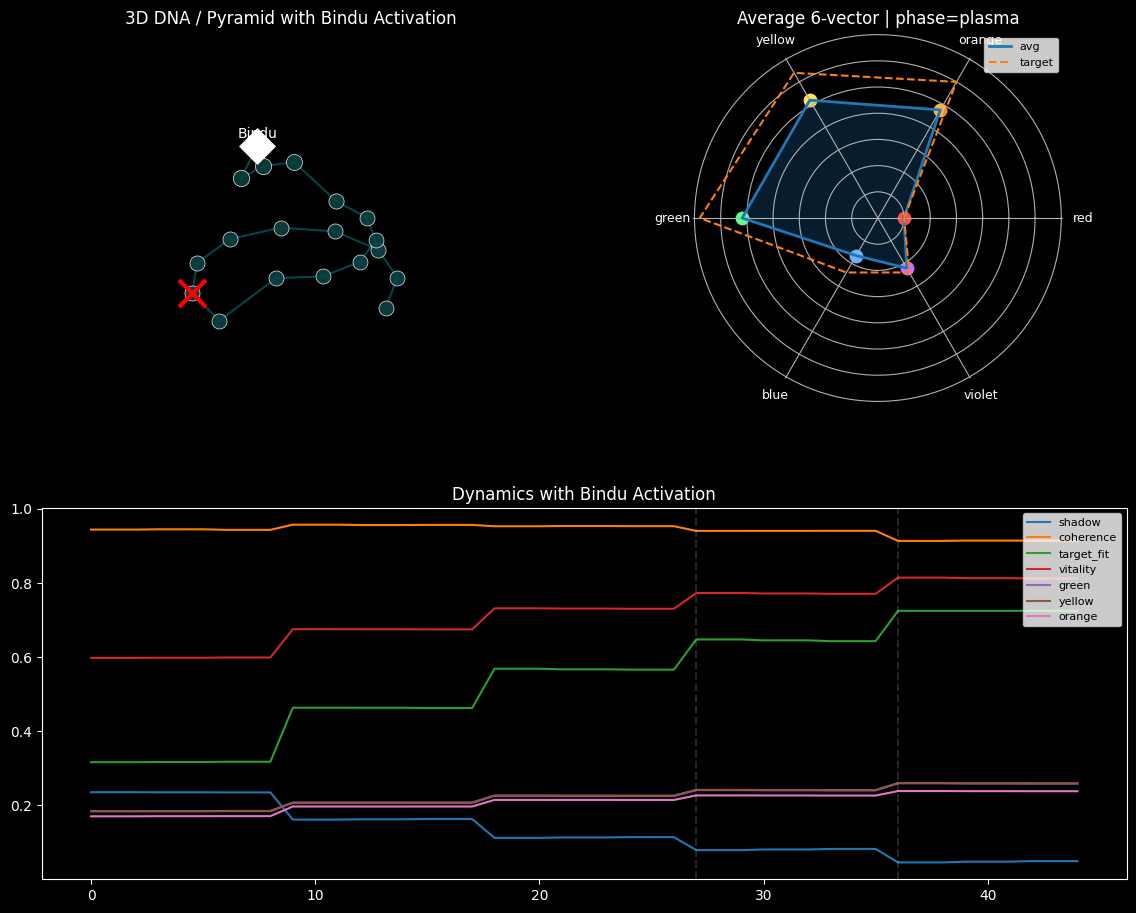

In [ ]:

fig = plt.figure(figsize=(14, 11), facecolor="black")
gs = fig.add_gridspec(2, 2, hspace=0.28, wspace=0.18)

# 3D field
ax1 = fig.add_subplot(gs[0, 0], projection="3d")
ax1.set_facecolor("black")

for node in field:
    v = node["state"]
    color = (v["red_mass"], (v["yellow_struct"] + v["orange_flow"]) / 2.0, v["green_balance"])
    size = 90 + 280 * v["violet_future"]
    ax1.scatter(
        [node["xyz"][0]], [node["xyz"][1]], [node["xyz"][2]],
        s=size, color=color, edgecolors="white", linewidths=0.5, alpha=0.92
    )

bindu_xyz = field[-1]["xyz"]
ax1.scatter([bindu_xyz[0]], [bindu_xyz[1]], [bindu_xyz[2]], s=320, color="white", marker="D")
ax1.text(bindu_xyz[0], bindu_xyz[1], bindu_xyz[2] + 0.14, "Bindu", color="white", ha="center")

shadow_xyz = field[shadow_idx]["xyz"]
ax1.scatter([shadow_xyz[0]], [shadow_xyz[1]], [shadow_xyz[2]], s=380, color="red", marker="x", linewidths=3)

for i in range(len(field) - 1):
    p1 = field[i]["xyz"]
    p2 = field[i + 1]["xyz"]
    ax1.plot([p1[0], p2[0]], [p1[1], p2[1]], [p1[2], p2[2]], color="cyan", alpha=0.28)

ax1.set_title("3D DNA / Pyramid with Bindu Activation", color="white")
ax1.set_axis_off()

# radar
ax2 = fig.add_subplot(gs[0, 1], polar=True)
ax2.set_facecolor("black")

theta = np.linspace(0, 2*np.pi, len(HEX_KEYS), endpoint=False)
vals = [avg[k] for k in HEX_KEYS]
theta_c = np.r_[theta, theta[0]]
vals_c = np.r_[vals, vals[0]]

target_vals = [TARGET[k] for k in HEX_KEYS]
target_c = np.r_[target_vals, target_vals[0]]

ax2.plot(theta_c, vals_c, linewidth=2, label="avg")
ax2.fill(theta_c, vals_c, alpha=0.25)
ax2.plot(theta_c, target_c, linewidth=1.5, linestyle="--", label="target")

for ang, key, val in zip(theta, HEX_KEYS, vals):
    ax2.scatter([ang], [val], s=80, color=COLORS[key])

ax2.set_xticks(theta)
ax2.set_xticklabels(["red", "orange", "yellow", "green", "blue", "violet"], color="white", fontsize=9)
ax2.set_yticklabels([])
ax2.legend(loc="upper right", fontsize=8)
ax2.set_title(f"Average 6-vector | phase={phase}", color="white")

# dynamics
ax3 = fig.add_subplot(gs[1, :])
ax3.set_facecolor("black")
steps = [h["step"] for h in history]

ax3.plot(steps, [h["shadow"] for h in history], label="shadow")
ax3.plot(steps, [h["coherence"] for h in history], label="coherence")
ax3.plot(steps, [h["target_fit"] for h in history], label="target_fit")
ax3.plot(steps, [h["vitality"] for h in history], label="vitality")
ax3.plot(steps, [h["green_balance"] for h in history], label="green")
ax3.plot(steps, [h["yellow_struct"] for h in history], label="yellow")
ax3.plot(steps, [h["orange_flow"] for h in history], label="orange")

for s in bindu_open_steps:
    ax3.axvline(s, color="white", alpha=0.15, linestyle="--")

ax3.legend(loc="upper right", fontsize=8)
ax3.set_title("Dynamics with Bindu Activation", color="white")
ax3.tick_params(colors="white")
for spine in ax3.spines.values():
    spine.set_color("white")

plt.show()

In [ ]:

print("FINAL PHASE:", phase)
print("FINAL AVG VECTOR:")
for k in HEX_KEYS:
    print(f"  {k}: {avg[k]:.3f}")

print(
    f"shadow={shadow:.3f} | "
    f"coherence={coherence:.3f} | "
    f"target_fit={target_fit:.3f} | "
    f"vitality={vitality:.3f}"
)

print("BINDU OPEN STEPS:", bindu_open_steps if bindu_open_steps else "none")

FINAL PHASE: plasma
FINAL AVG VECTOR:
  red_mass: 0.050
  orange_flow: 0.238
  yellow_struct: 0.260
  green_balance: 0.259
  blue_law: 0.083
  violet_future: 0.110
shadow=0.050 | coherence=0.914 | target_fit=0.725 | vitality=0.812
BINDU OPEN STEPS: [27, 36]
